In [5]:
!pip -q install pandas numpy scipy scikit-learn networkx matplotlib seaborn shap statsmodels

In [6]:
import pandas as pd
import numpy as np
import gzip
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from io import StringIO
from sklearn.preprocessing import quantile_transform, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [7]:
def load_geo_series_matrix(filepath):
    with gzip.open(filepath, "rt") as f:
        lines = f.readlines()

    start, end = None, None
    for i, line in enumerate(lines):
        if "!series_matrix_table_begin" in line:
            start = i + 1
        if "!series_matrix_table_end" in line:
            end = i
            break

    table_data = "".join(lines[start:end])
    return pd.read_csv(StringIO(table_data), sep="\t")

transcript_df = load_geo_series_matrix("GSE53441_series_matrix.txt.gz")

print(transcript_df.shape)
transcript_df.head()

(54675, 35)


,ID_REF,GSM1293592,GSM1293593,GSM1293594,GSM1293595,GSM1293596,GSM1293597,GSM1293598,GSM1293599,GSM1293600,...,GSM1293616,GSM1293617,GSM1293618,GSM1293619,GSM1293620,GSM1293621,GSM1293622,GSM1293623,GSM1293624,GSM1293625
0,1007_s_at,6.26,6.62,6.36,6.44,6.67,6.48,6.36,6.82,6.35,...,6.27,6.11,6.47,6.28,6.47,6.35,6.59,6.35,6.50,5.94
1,1053_at,7.30,6.70,6.89,7.34,7.26,7.32,7.22,7.24,7.42,...,7.36,7.42,7.24,7.28,7.30,7.21,7.34,7.28,7.39,7.04
2,117_at,7.59,8.37,7.97,8.18,7.85,8.71,8.54,8.19,7.66,...,7.63,7.79,7.31,7.68,8.07,7.74,7.50,8.80,7.57,7.43
3,121_at,7.50,7.50,7.40,7.38,7.85,7.43,7.58,7.66,7.33,...,7.23,7.29,7.29,7.42,7.49,7.25,7.34,7.31,7.33,6.83
4,1255_g_at,2.89,2.90,2.80,2.74,2.88,2.99,2.77,2.60,2.79,...,2.94,2.79,2.75,2.78,2.94,2.74,2.75,2.85,2.86,3.01


In [8]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE165nnn/GSE165689/suppl/GSE165689_raw_counts_genes.txt.gz

--2026-04-14 08:27:38--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE165nnn/GSE165689/suppl/GSE165689_raw_counts_genes.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 2607:f220:41e:250::31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 884141 (863K) [application/x-gzip]
Saving to: ‘GSE165689_raw_counts_genes.txt.gz’

GSE165689_raw_count 100%[===================>] 863.42K  2.77MB/s    in 0.3s    

2026-04-14 08:27:39 (2.77 MB/s) - ‘GSE165689_raw_counts_genes.txt.gz’ saved [884141/884141]



In [9]:
second_df = pd.read_csv(
    "GSE165689_raw_counts_genes.txt.gz",
    sep="\t",
    compression="gzip"
)

In [10]:
# Transcriptomics
t_ids = transcript_df.iloc[:, 0]
t_expr = transcript_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

t_expr = t_expr.dropna(how='all')
t_expr = t_expr.T.fillna(t_expr.mean(axis=1)).T
t_expr = t_expr.loc[t_expr.var(axis=1) > 0.01]

# Second layer
s_ids = second_df.iloc[:, 0]
s_expr = second_df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').fillna(0)

# remove useless rows
s_expr = s_expr.loc[s_expr.sum(axis=1) > 0]
s_expr = s_expr[(s_expr > 0).sum(axis=1) >= 2]

# IMPORTANT FIX (for your dataset)
s_expr = s_expr.replace(0, 0.1)

print("Transcript:", t_expr.shape)
print("Second:", s_expr.shape)

Transcript: (54007, 34)
Second: (24604, 19)


In [11]:
# Transcriptomics → log + quantile
t_log = np.log2(t_expr + 1)

t_qn = quantile_transform(
    t_log,
    axis=0,
    copy=True,
    n_quantiles=min(1000, t_log.shape[0])
)

transcript_norm = pd.DataFrame(t_qn, index=t_ids.loc[t_expr.index])

# Second layer → log + z-score
s_log = np.log2(s_expr + 1)

scaler = StandardScaler()
s_scaled = scaler.fit_transform(s_log.T).T

second_norm = pd.DataFrame(s_scaled, index=s_ids.loc[s_expr.index])

print(transcript_norm.shape)
print(second_norm.shape)

(54007, 34)
(24604, 19)


In [12]:
def select_top(matrix, n=1500):
    return matrix.loc[matrix.var(axis=1).sort_values(ascending=False).head(n).index]

transcript_top = select_top(transcript_norm)
second_top = select_top(second_norm)

print(transcript_top.shape)
print(second_top.shape)

(1500, 34)
(1500, 19)


In [13]:
def build_graph(matrix, corr_quantile=0.985, min_abs_corr=0.60):
    corr = np.corrcoef(matrix)
    nodes = list(matrix.index)
    np.fill_diagonal(corr, 0)

    upper = np.abs(corr[np.triu_indices_from(corr, k=1)])
    dynamic_threshold = np.quantile(upper, corr_quantile)
    threshold = max(min_abs_corr, dynamic_threshold)

    G = nx.Graph()
    G.add_nodes_from(nodes)

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if abs(corr[i, j]) >= threshold:
                G.add_edge(nodes[i], nodes[j], weight=float(corr[i, j]))

    # keep the largest connected component for a cleaner and more readable network
    if G.number_of_edges() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    return G, threshold

transcript_graph, transcript_thr = build_graph(transcript_top, corr_quantile=0.985, min_abs_corr=0.60)
second_graph, second_thr = build_graph(second_top, corr_quantile=0.985, min_abs_corr=0.60)

print(f"Transcript: {transcript_graph.number_of_nodes()} nodes, {transcript_graph.number_of_edges()} edges | threshold={transcript_thr:.3f}")
print(f"Second: {second_graph.number_of_nodes()} nodes, {second_graph.number_of_edges()} edges | threshold={second_thr:.3f}")

Transcript: 687 nodes, 15630 edges | threshold=0.753
Second: 272 nodes, 15563 edges | threshold=0.892


Transcript: 641 nodes, 15584 edges | threshold=0.753
Second: 267 nodes, 15558 edges | threshold=0.892


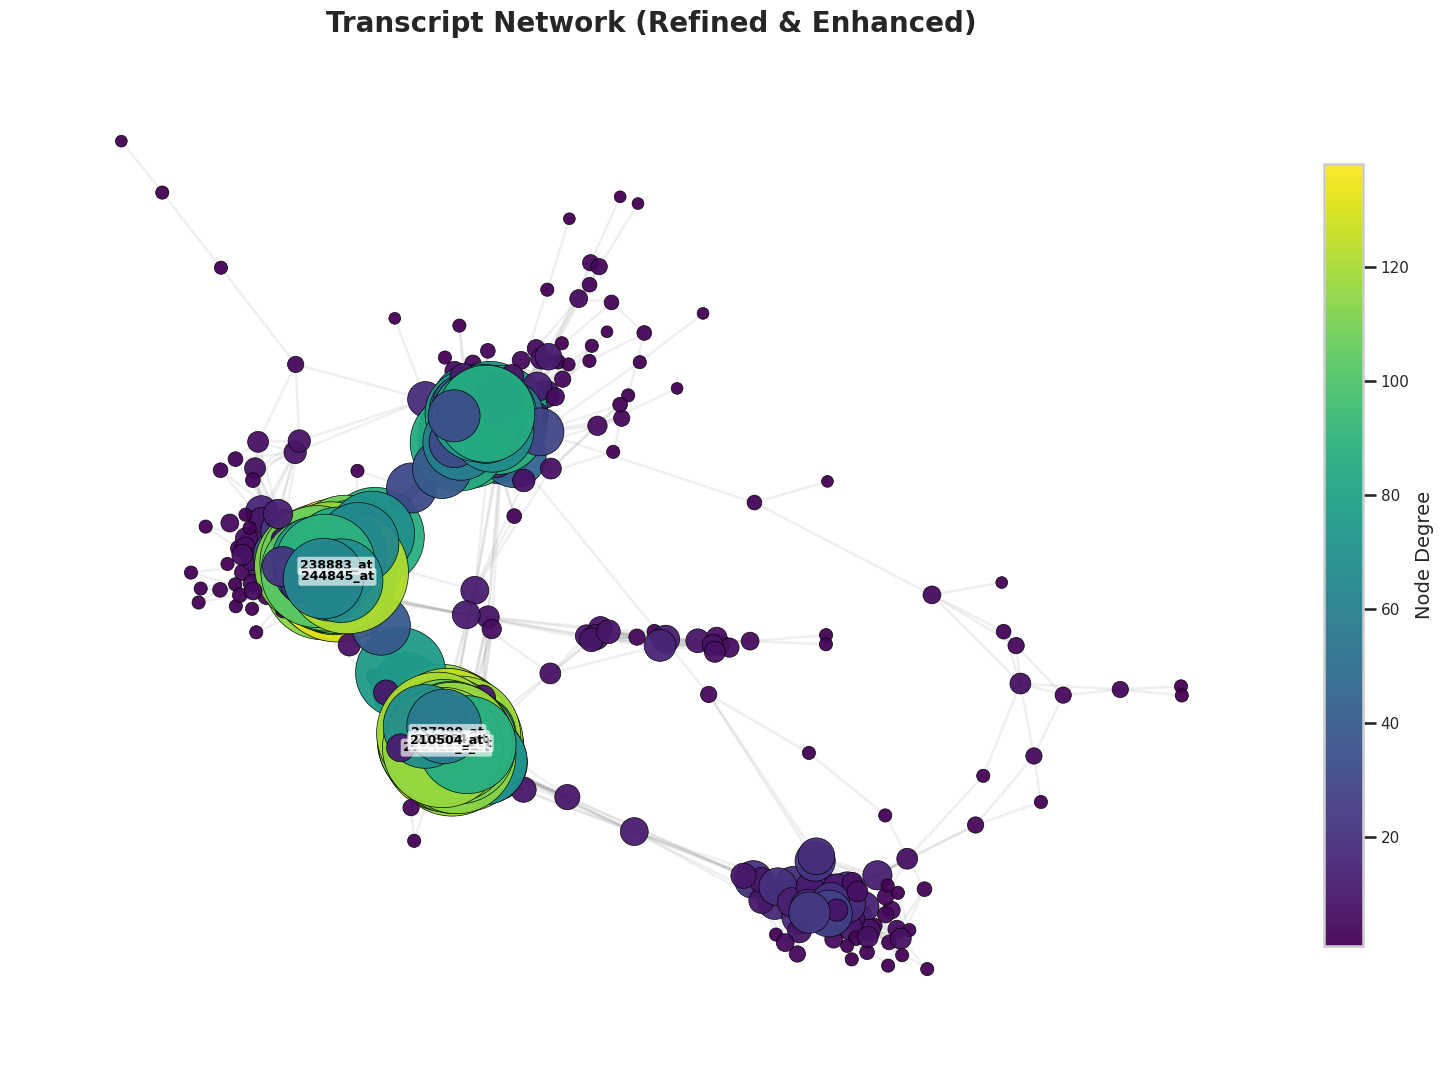

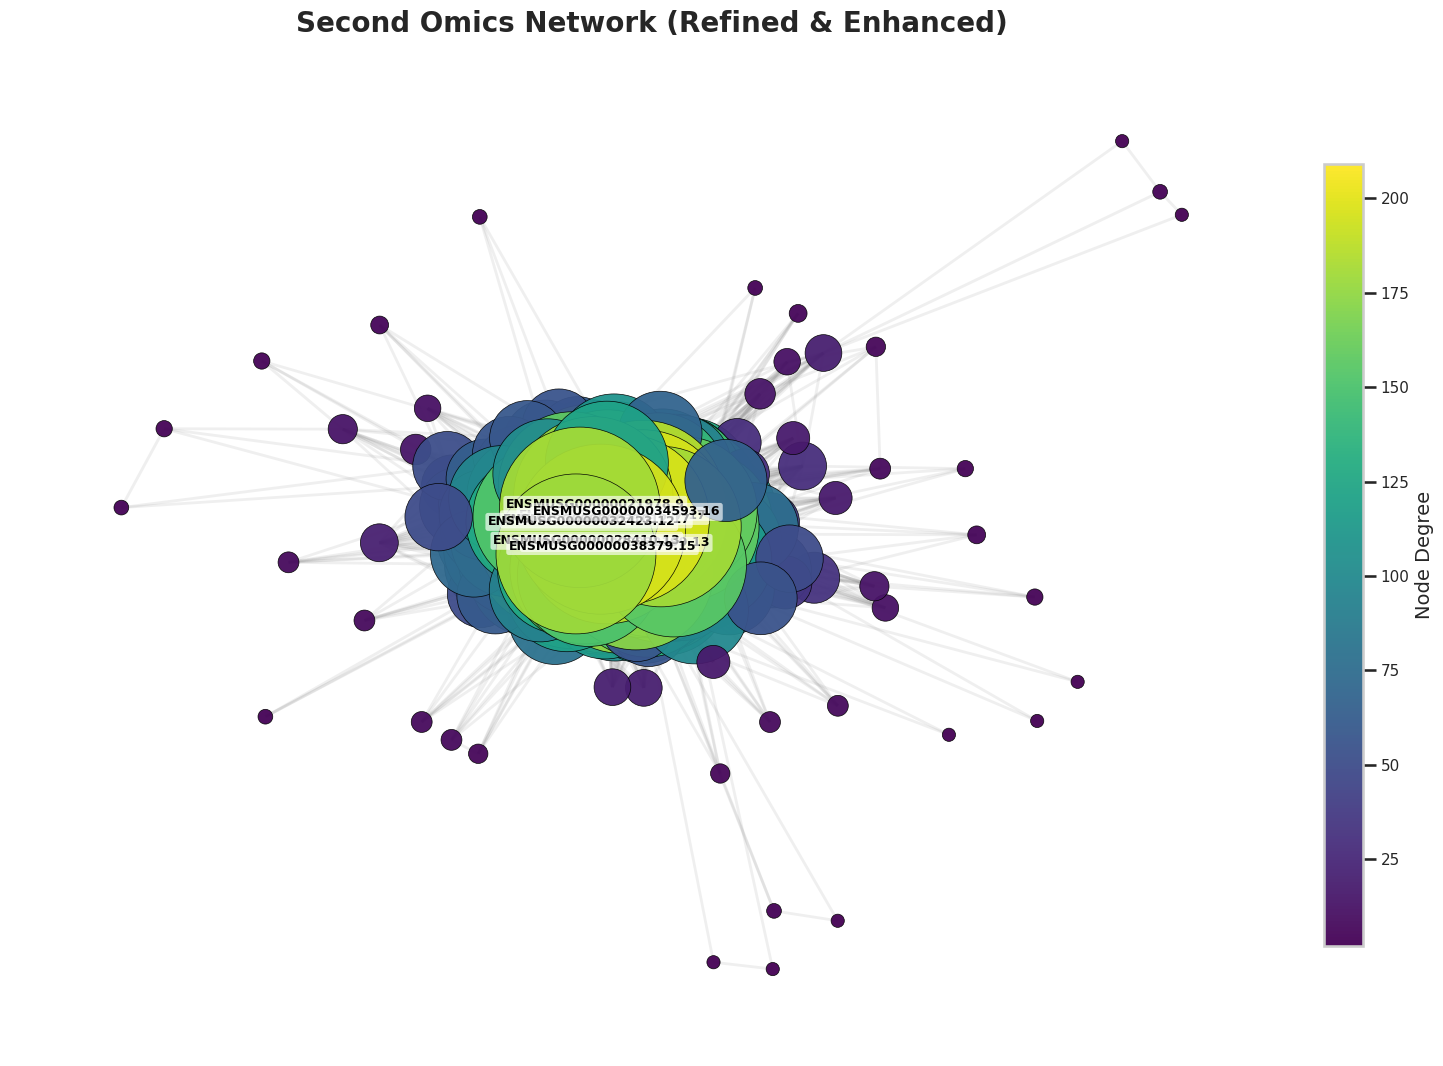

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def build_graph(matrix, corr_quantile=0.985, min_abs_corr=0.60, min_degree_filter=2):
    corr = np.corrcoef(matrix)
    nodes = list(matrix.index)
    np.fill_diagonal(corr, 0)

    upper = np.abs(corr[np.triu_indices_from(corr, k=1)])
    dynamic_threshold = np.quantile(upper, corr_quantile)
    threshold = max(min_abs_corr, dynamic_threshold)

    G = nx.Graph()
    G.add_nodes_from(nodes)

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if abs(corr[i, j]) >= threshold:
                G.add_edge(
                    nodes[i],
                    nodes[j],
                    weight=float(corr[i, j]),
                    abs_weight=float(abs(corr[i, j])),
                    distance=float(1 - abs(corr[i, j]))
                )

    # keep only largest connected component
    if G.number_of_edges() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    # remove very low-degree nodes for a cleaner look
    if min_degree_filter is not None and G.number_of_nodes() > 0:
        low_degree_nodes = [n for n, d in dict(G.degree()).items() if d < min_degree_filter]
        G.remove_nodes_from(low_degree_nodes)

        if G.number_of_edges() > 0 and G.number_of_nodes() > 0:
            largest_cc = max(nx.connected_components(G), key=len)
            G = G.subgraph(largest_cc).copy()

    return G, threshold


def plot_graph(G, title, top_label_count=8):
    plt.figure(figsize=(16, 11), facecolor="white")

    degree_dict = dict(G.degree())
    degree_vals = np.array(list(degree_dict.values()))

    # smoother node scaling
    node_sizes = 60 + (degree_vals ** 1.35) * 12

    # weighted spring layout gives more natural connected clusters
    pos = nx.spring_layout(
        G,
        k=0.55,
        iterations=200,
        seed=42,
        weight="abs_weight"
    )

    # edge width based on correlation strength
    edge_widths = [0.4 + 1.8 * G[u][v]["abs_weight"] for u, v in G.edges()]
    edge_alphas = 0.12

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=edge_alphas,
        width=edge_widths,
        edge_color="gray"
    )

    nodes_plot = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=degree_vals,
        cmap=plt.cm.viridis,
        linewidths=0.5,
        edgecolors="black",
        alpha=0.95
    )

    # colorbar
    cbar = plt.colorbar(nodes_plot, shrink=0.78, pad=0.02)
    cbar.set_label("Node Degree", rotation=90, fontsize=14)
    cbar.ax.tick_params(labelsize=11)

    # label only most important nodes
    top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:top_label_count]
    labels = {n: n for n in top_nodes}

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_weight="bold",
        font_color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.65,
            boxstyle="round,pad=0.2"
        )
    )

    plt.title(title, fontsize=20, fontweight="bold", pad=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Build graphs
transcript_graph, transcript_thr = build_graph(
    transcript_top,
    corr_quantile=0.985,
    min_abs_corr=0.60,
    min_degree_filter=2
)

second_graph, second_thr = build_graph(
    second_top,
    corr_quantile=0.985,
    min_abs_corr=0.60,
    min_degree_filter=2
)

print(f"Transcript: {transcript_graph.number_of_nodes()} nodes, {transcript_graph.number_of_edges()} edges | threshold={transcript_thr:.3f}")
print(f"Second: {second_graph.number_of_nodes()} nodes, {second_graph.number_of_edges()} edges | threshold={second_thr:.3f}")

plot_graph(transcript_graph, "Transcript Network (Refined & Enhanced)", top_label_count=8)
plot_graph(second_graph, "Second Omics Network (Refined & Enhanced)", top_label_count=8)

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/networkx/algorithms/link_analysis/pagerank_alg.py:495: RuntimeWarning: invalid value encountered in subtract
  err = np.absolute(x - xlast).sum()


PageRank did not converge. Switching to eigenvector centrality.


,gene,degree_centrality,betweenness_centrality,pagerank
156,238883_at,0.215625,0.013852,0.001521
229,244845_at,0.206250,0.011152,0.001530
435,202219_at,0.201563,0.004501,0.110716
311,237299_at,0.201563,0.015994,0.109373
173,218418_s_at,0.201563,0.002237,0.110354
259,235683_at,0.201563,0.001374,0.110417
376,210504_at,0.198438,0.004277,0.109343
174,218864_at,0.198438,0.004606,0.110401
317,221747_at,0.196875,0.003720,0.109267
68,227498_at,0.195312,0.003813,0.107491


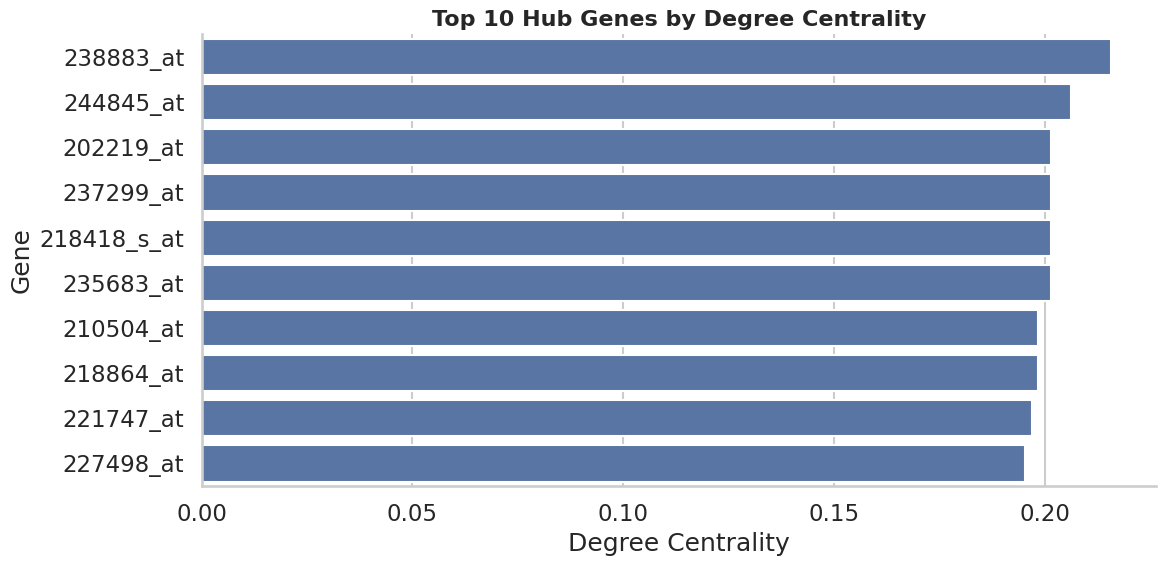

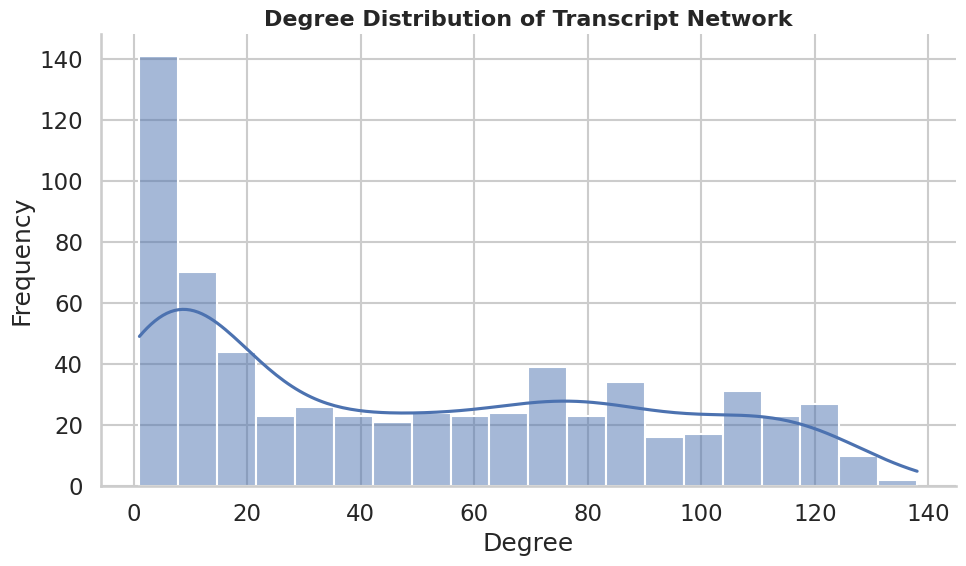

In [21]:
deg = nx.degree_centrality(transcript_graph)
bet = nx.betweenness_centrality(transcript_graph)

try:
    pagerank = nx.pagerank(transcript_graph, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("PageRank did not converge. Switching to eigenvector centrality.")
    pagerank = nx.eigenvector_centrality(transcript_graph, max_iter=1000)

centrality_df = pd.DataFrame({
    "gene": list(transcript_graph.nodes()),
    "degree_centrality": [deg[g] for g in transcript_graph.nodes()],
    "betweenness_centrality": [bet[g] for g in transcript_graph.nodes()],
    "pagerank": [pagerank[g] for g in transcript_graph.nodes()]
}).sort_values("degree_centrality", ascending=False)

display(centrality_df.head(10))

# Visualization 1: top hub genes
top10 = centrality_df.head(10).copy()
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="degree_centrality", y="gene")
plt.title("Top 10 Hub Genes by Degree Centrality", fontsize=16, fontweight="bold")
plt.xlabel("Degree Centrality")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

# Visualization 2: degree distribution
plt.figure(figsize=(10, 6))
sns.histplot([d for _, d in transcript_graph.degree()], bins=20, kde=True)
plt.title("Degree Distribution of Transcript Network", fontsize=16, fontweight="bold")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Silhouette score for derived sample groups: 0.6591


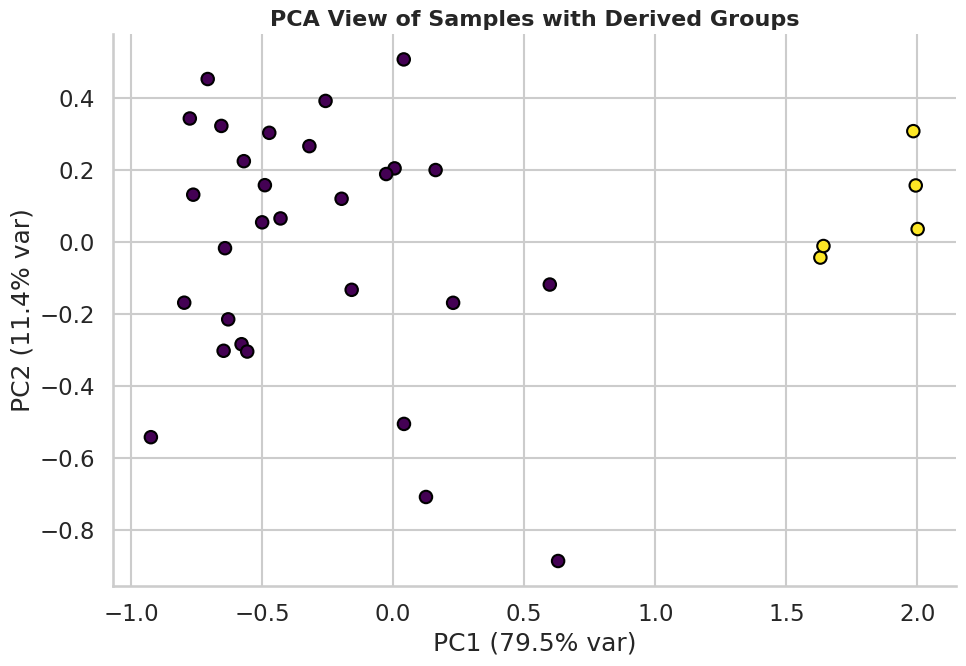

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



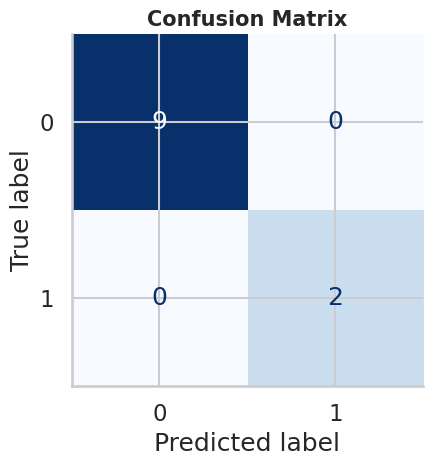

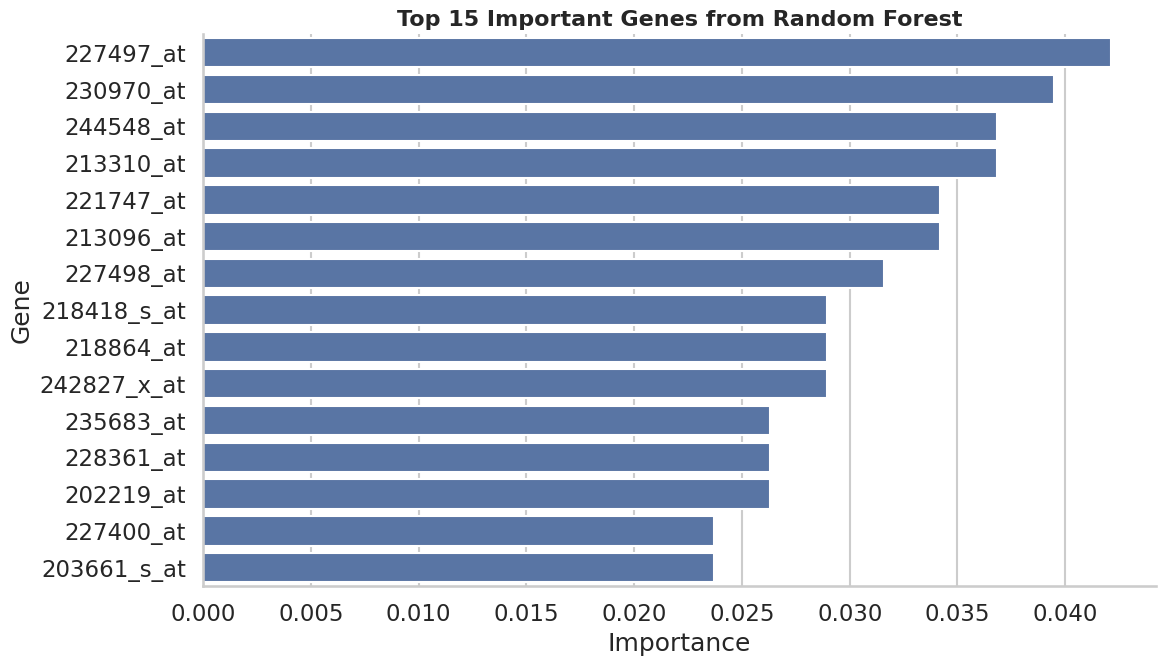

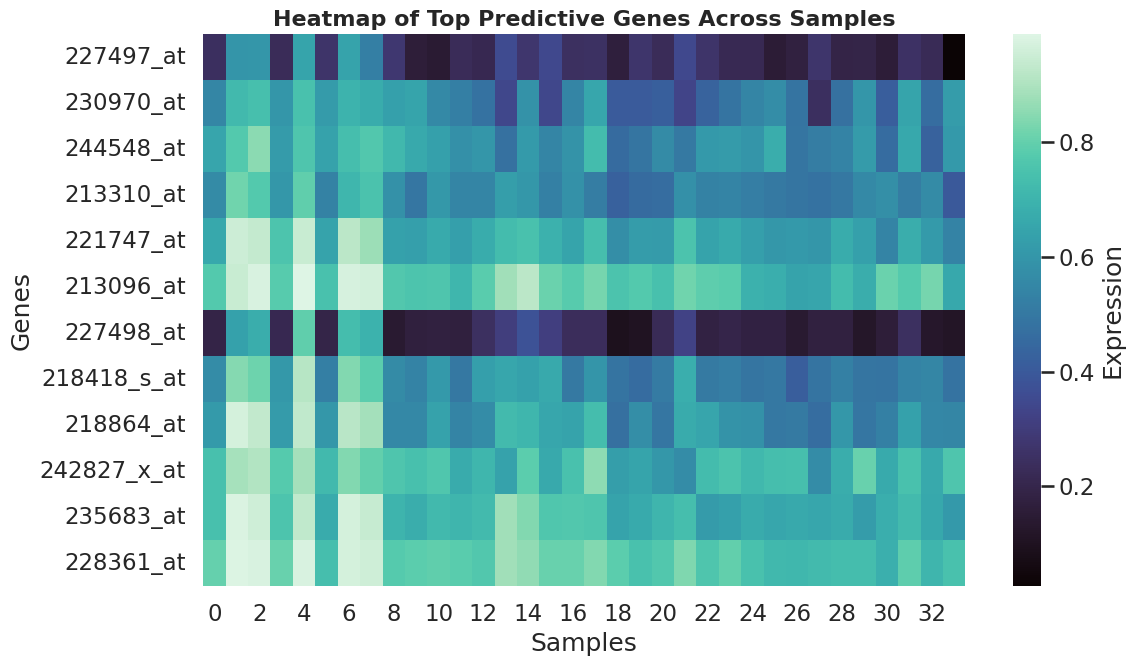

In [22]:
# Use top hub genes
top_genes = centrality_df["gene"].head(50)

X = transcript_top.loc[top_genes].T

# Better labels than the earlier demo split:
# derive sample groups from expression structure using PCA + KMeans
pca_for_labels = PCA(n_components=min(10, X.shape[1]), random_state=42)
X_pca_for_labels = pca_for_labels.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
y = kmeans.fit_predict(X_pca_for_labels)

print("Silhouette score for derived sample groups:", round(silhouette_score(X_pca_for_labels, y), 4))

# Visualization 3: PCA scatter plot of samples
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=y, s=80, cmap="viridis", edgecolors="black")
plt.title("PCA View of Samples with Derived Groups", fontsize=16, fontweight="bold")
plt.xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred))

# Visualization 4: confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Visualization 5: model feature importance
feature_importance = pd.DataFrame({
    "gene": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x="importance", y="gene")
plt.title("Top 15 Important Genes from Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

# Visualization 6: expression heatmap for top genes
heatmap_genes = feature_importance["gene"].head(12).tolist()
plt.figure(figsize=(12, 7))
sns.heatmap(X[heatmap_genes].T, cmap="mako", cbar_kws={"label": "Expression"})
plt.title("Heatmap of Top Predictive Genes Across Samples", fontsize=16, fontweight="bold")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

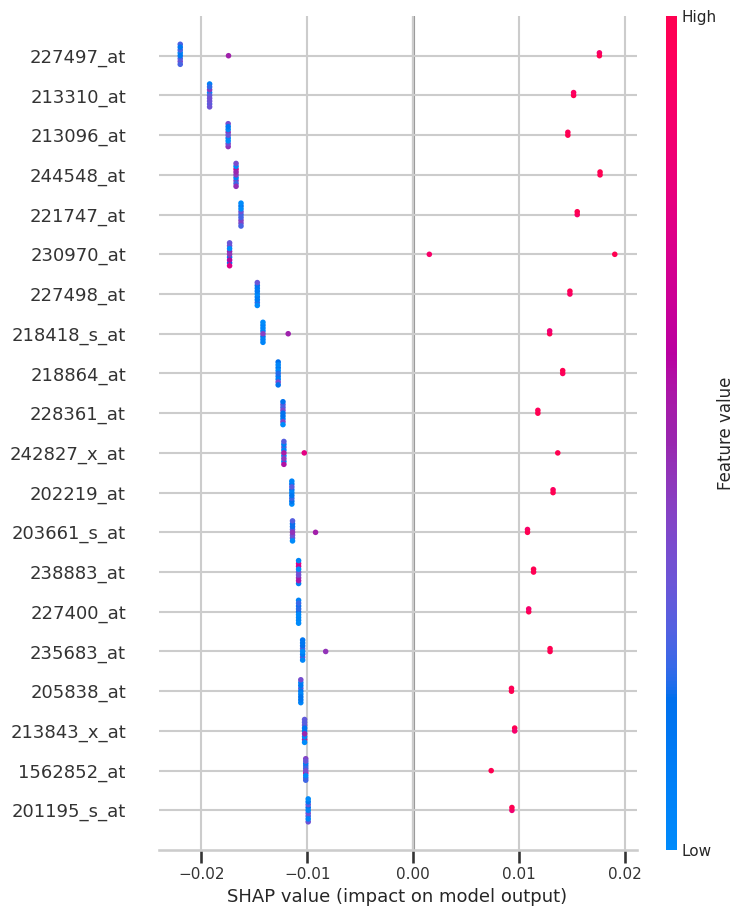

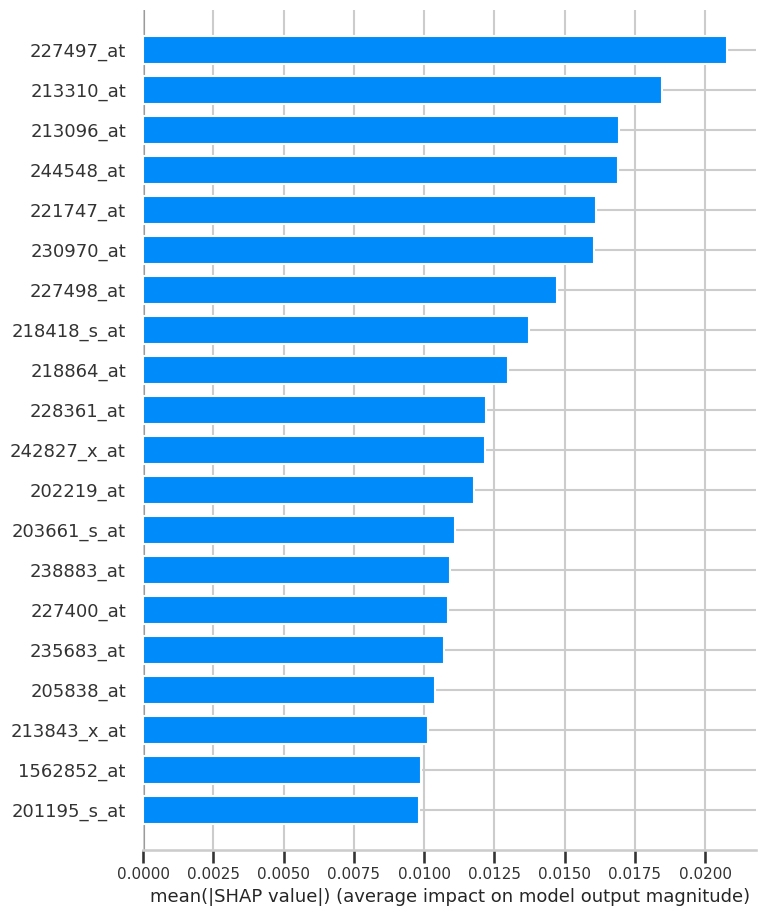

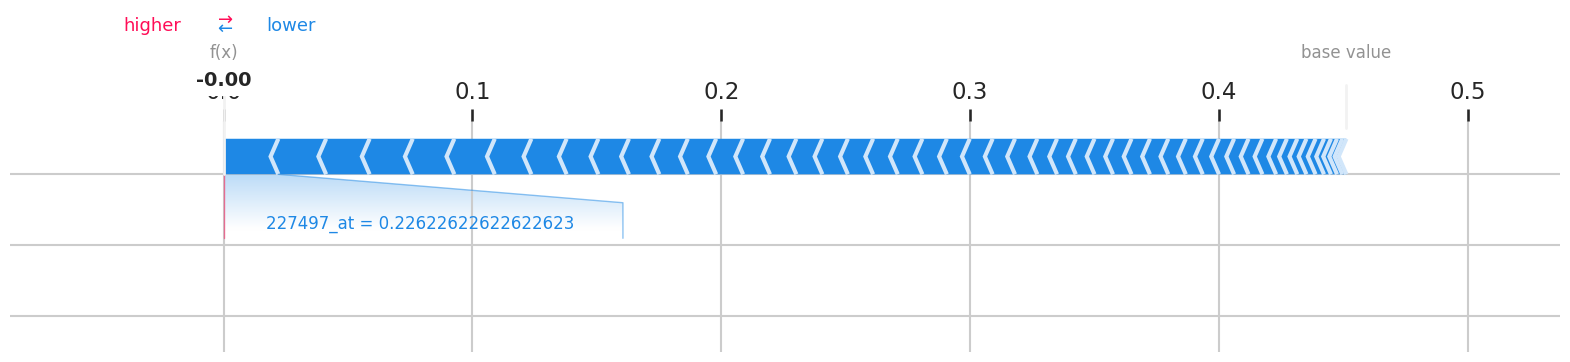

In [23]:
# SHAP with cleaner and more interpretable outputs
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification, use the positive class explanation if SHAP returns a list
if isinstance(shap_values, list):
    shap_for_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    # If shap_values is an array for binary classification, it's typically (num_samples, num_features, num_classes)
    # We want the shap values for the positive class (index 1) for summary plots
    shap_for_plot = shap_values[:, :, 1] # Select SHAP values for the positive class

# Visualization 7: SHAP beeswarm
shap.summary_plot(shap_for_plot, X_test, plot_type="dot")

# Visualization 8: SHAP bar plot
shap.summary_plot(shap_for_plot, X_test, plot_type="bar")

# Visualization 9: local explanation for one sample
sample_index = 0

# Get the expected value for the positive class
expected_value_for_positive_class = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1 else explainer.expected_value

# Select the SHAP values for the chosen sample and the positive class (index 1)
# If shap_for_plot is already class-specific, then we just need the sample
shap_values_for_single_sample = shap_for_plot[sample_index]

shap.force_plot(
    expected_value_for_positive_class,
    shap_values_for_single_sample,
    X_test.iloc[sample_index],
    matplotlib=True
)
plt.show()